In [1]:
from IPython.core.magic import register_cell_magic
from IPython.display import display
import threading, time, tracemalloc

@register_cell_magic
def monitor(_, cell):
    tracemalloc.start()
    start = time.time()
    stop_event = threading.Event()
    handle = display("starting...", display_id=True)

    def report_loop():
        while not stop_event.wait(0.5):  # poll every 0.5s
            current, peak = tracemalloc.get_traced_memory()
            elapsed = time.time() - start
            handle.update(f"[t={elapsed:6.2f}s] current={current/1e6:.1f}MB peak={peak/1e6:.1f}MB")

    t = threading.Thread(target=report_loop, daemon=True)
    t.start()
    try:
        get_ipython().run_cell(cell)
    finally:
        stop_event.set()
        t.join()

    elapsed = time.time() - start
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    print(f"\n--- Monitoring report ---")
    print(f"[memory] current: {current/1e6:.1f} MB, peak: {peak/1e6:.1f} MB")
    print(f"[speed] time elapsed: {elapsed:.3f}s")

In [2]:
%%monitor

from dandi.dandiapi import DandiAPIClient
from pynwb import NWBHDF5IO
import remfile, h5py

DANDISET_ID = "000402"
ASSET_PATH = "sub-17797/sub-17797_ses-6-scan-4_behavior+image+ophys.nwb"

def get_s3_url(dandiset_id: str, asset_path: str) -> str:
    with DandiAPIClient() as client:
        asset = client.get_dandiset(dandiset_id, "draft").get_asset_by_path(asset_path)
        return asset.get_content_url(follow_redirects=1, strip_query=True)

def stream_nwbfile(dandiset_id: str = DANDISET_ID, asset_path: str = ASSET_PATH):
    s3_url = get_s3_url(dandiset_id, asset_path)
    print(f"Resolved S3 URL: {s3_url}")
    rfile = remfile.File(s3_url)
    h5f = h5py.File(rfile, "r")
    io = NWBHDF5IO(file=h5f, load_namespaces=True)
    nwbfile = io.read()
    return nwbfile, io

'[t=  3.10s] current=65.7MB peak=65.7MB'


--- Monitoring report ---
[memory] current: 74.4 MB, peak: 74.5 MB
[speed] time elapsed: 3.454s


In [3]:
%%monitor

nwbfile, io = stream_nwbfile()

'[t= 15.67s] current=10.8MB peak=11.0MB'

Resolved S3 URL: https://dandiarchive.s3.amazonaws.com/blobs/d25/a26/d25a268a-73d5-41bf-994a-7b7fc3f0eb17

--- Monitoring report ---
[memory] current: 11.4 MB, peak: 11.5 MB
[speed] time elapsed: 16.103s


In [4]:
%%monitor

print("\n--- Session info ---")
print("Session description:", nwbfile.session_description)
print("Session start time:", nwbfile.session_start_time)
print("Subject:", nwbfile.subject)

print("\n--- Acquisition / processing modules (lazy) ---")
for name, ts in nwbfile.acquisition.items():
    print(f"acquisition/{name}: shape={getattr(ts, 'data', None) and ts.data.shape}")

for mod_name, mod in nwbfile.processing.items():
    print(f"processing module: {mod_name}")
    for iface_name in mod.data_interfaces:
        print(f"  - {iface_name}")


'starting...'


--- Session info ---
Session description: Contains calcium imaging recorded from multiple cortical visual areas and behavioral measurements while a mouse viewed natural movies and parametric stimuli. The structural ids are added as plane segmentation columns from the CAVE database on 2023-02-12. To access the latest revision see the notebook that is linked to the dandiset. The structural ids might not be present for all plane segmentations.
Session start time: 2018-03-06 00:00:00+00:00
Subject: subject pynwb.file.Subject at 0x130312288366144
Fields:
  age: P75D/P81D
  sex: M
  species: Mus musculus
  subject_id: 17797


--- Acquisition / processing modules (lazy) ---
acquisition/EyeTracking: shape=None
acquisition/PupilTracking: shape=None
acquisition/TwoPhotonSeries1: shape=(40000, 248, 440)
acquisition/TwoPhotonSeries2: shape=(40000, 248, 440)
acquisition/TwoPhotonSeries3: shape=(40000, 248, 440)
acquisition/TwoPhotonSeries4: shape=(40000, 248, 440)
acquisition/TwoPhotonSeries5: sha

In [5]:
two_photon_series = nwbfile.acquisition["TwoPhotonSeries4"]

In [6]:

%%monitor
import numpy as np
import dask.array as da

print(type(two_photon_series))
print(type(two_photon_series.data))
print(two_photon_series.data.chunks)

import inspect

print(inspect.getmro(type(two_photon_series)))

print(two_photon_series.rate)
print(dir(two_photon_series.data))
print(inspect.getmro(type(two_photon_series.data)))



def naive_nbytes(shape, dtype):
    return int(np.prod(shape)) * np.dtype(dtype).itemsize

nbytes = naive_nbytes(two_photon_series.data.shape, two_photon_series.data.dtype)
gib = nbytes / 1024**3
print(f"{gib:.2f} GiB")

streamed_imaging = da.from_array(two_photon_series.data, chunks=two_photon_series.data.chunks)
print(streamed_imaging.chunksize)


'[t=  0.50s] current=9.7MB peak=9.7MB'

<class 'pynwb.ophys.TwoPhotonSeries'>
<class 'h5py._hl.dataset.Dataset'>
(2254, 14, 14)
(<class 'pynwb.ophys.TwoPhotonSeries'>, <class 'pynwb.image.ImageSeries'>, <class 'pynwb.base.TimeSeries'>, <class 'pynwb.core.NWBDataInterface'>, <class 'pynwb.core.NWBContainer'>, <class 'pynwb.core.NWBMixin'>, <class 'hdmf.container.Container'>, <class 'hdmf.container.AbstractContainer'>, <class 'object'>)
None
['__array__', '__bool__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getnewargs__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__iter__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setitem__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', '_cache_props', '_d', '_dcpl', '_dxpl', '_e', '_extent_type', '_fast_read_ok', '_fast_reader', 

In [ ]:
%%monitor
time_slice = (slice(50,550))

'starting...'


--- Monitoring report ---
[memory] current: 0.0 MB, peak: 0.1 MB
[speed] time elapsed: 0.003s


In [12]:
%%monitor
print(streamed_imaging.shape)
average = streamed_imaging[time_slice].mean(axis=0)
print(average.shape)

nbytes = naive_nbytes(streamed_imaging.shape, streamed_imaging.dtype)
gib = nbytes / 1024**3
print(f"{gib:.2f} GiB")
print(streamed_imaging.chunksize)

'starting...'

(40000, 248, 440)
(248, 440)
8.13 GiB
(2254, 14, 14)

--- Monitoring report ---
[memory] current: 0.4 MB, peak: 0.4 MB
[speed] time elapsed: 0.026s


In [13]:
%%monitor
average_np = average.compute()


'[t=  3.01s] current=5.4MB peak=6.9MB'


--- Monitoring report ---
[memory] current: 1.9 MB, peak: 6.9 MB
[speed] time elapsed: 3.297s


'[t=  3.01s] current=4.8MB peak=6.7MB'

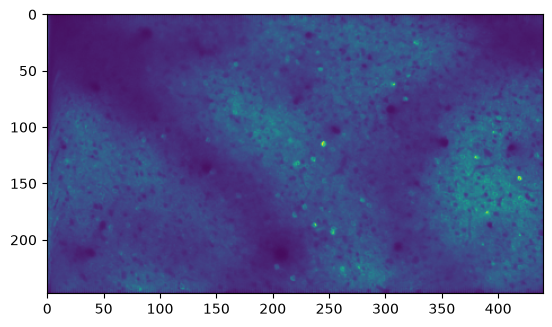


--- Monitoring report ---
[memory] current: 2.2 MB, peak: 15.5 MB
[speed] time elapsed: 3.441s


In [14]:
%%monitor
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(average)
plt.show()


In [16]:
%%monitor
# write to local temp store
from pathlib import Path
out_path = Path("./twophoton_series.zarr")

array = streamed_imaging[time_slice]
print(array.chunksize)
array.to_zarr(out_path, overwrite=True)

average.to_zarr(Path("./average.zarr"),overwrite=True)



'[t=  7.54s] current=6.1MB peak=7.2MB'

(500, 14, 14)

--- Monitoring report ---
[memory] current: 1.9 MB, peak: 7.2 MB
[speed] time elapsed: 8.042s
